In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro, kstest, probplot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from scipy.stats import zscore
import pingouin as pg

## Carrregar os dados


In [2]:
df_irrigacao = pd.read_csv('./dataset_desafio/dados_de_irrigacao.csv')

## Visualização dos dados

In [3]:
df_irrigacao.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Horas de Irrigação        299 non-null    int64  
 1   Área Irrigada             299 non-null    int64  
 2   Área Irrigada por Ângulo  299 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 7.1 KB


In [4]:
df_irrigacao.describe()

,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
count,299.000000,299.000000,299.000000
mean,150.000000,15000.000000,10000.000000
std,86.458082,8645.808233,5763.872155
min,1.000000,100.000000,66.666667
25%,75.500000,7550.000000,5033.333333
50%,150.000000,15000.000000,10000.000000
75%,224.500000,22450.000000,14966.666667
max,299.000000,29900.000000,19933.333333


In [5]:
df_irrigacao.head(10)

,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
0,1,100,66.666667
1,2,200,133.333333
2,3,300,200.000000
3,4,400,266.666667
4,5,500,333.333333
5,6,600,400.000000
6,7,700,466.666667
7,8,800,533.333333
8,9,900,600.000000
9,10,1000,666.666667


In [6]:
df_irrigacao.tail(10)

,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
289,290,29000,19333.333333
290,291,29100,19400.000000
291,292,29200,19466.666667
292,293,29300,19533.333333
293,294,29400,19600.000000
294,295,29500,19666.666667
295,296,29600,19733.333333
296,297,29700,19800.000000
297,298,29800,19866.666667
298,299,29900,19933.333333


## Gráfico de dispersão (horas de irrigação e área irrigada por ângulo)

<Axes: xlabel='Horas de Irrigação', ylabel='Área Irrigada por Ângulo'>

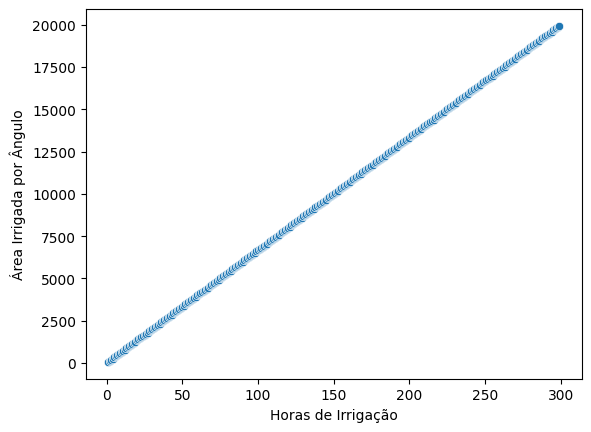

In [9]:
# x = horas de irrigação
# y = area irrigada por angulo
sns.scatterplot(data=df_irrigacao, x='Horas de Irrigação', y='Área Irrigada por Ângulo')

## Correlação entre as variáveis

<Axes: >

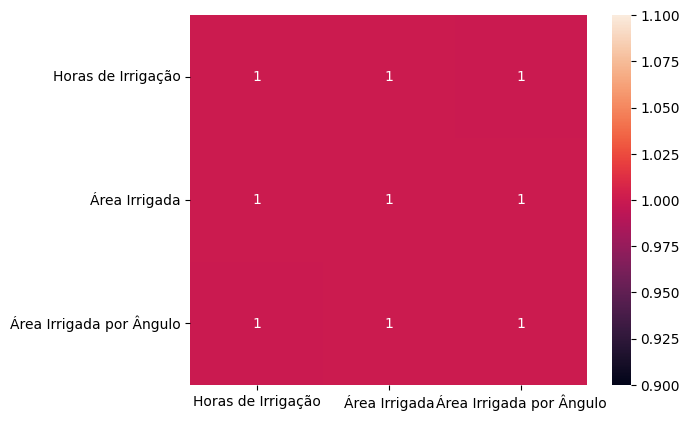

In [10]:
# Correlação - Pearson
sns.heatmap(df_irrigacao.corr('pearson'), annot=True)

<Axes: >

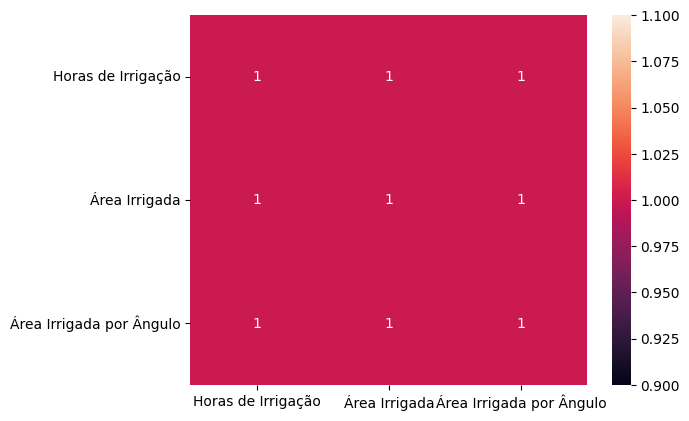

In [11]:
# Correlação - Spearman
sns.heatmap(df_irrigacao.corr('spearman'), annot=True)

## Divisão dos dados e treinamento do modelo

In [30]:
X = df_irrigacao['Horas de Irrigação'].values.reshape(-1,1)
y = df_irrigacao['Área Irrigada por Ângulo'].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=50)

In [31]:
model_irrigacao = LinearRegression()

In [32]:
model_irrigacao.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
print("A equação da reta é: y = {:4f}x + {:4f}".format(model_irrigacao.coef_[0][0], model_irrigacao.intercept_[0]))

A equação da reta é: y = 66.666667x + -0.000000


## Métricas de desempenho (MSE, MAE)

#### MAE

In [34]:
y_pred = model_irrigacao.predict(X_test)

In [36]:
mean_absolute_error(y_test, y_pred)

1.6200374375330284e-12

#### MSE

In [37]:
mean_squared_error(y_test, y_pred)

5.4113552520689084e-24

## Visualizar os resultados reais e preditos

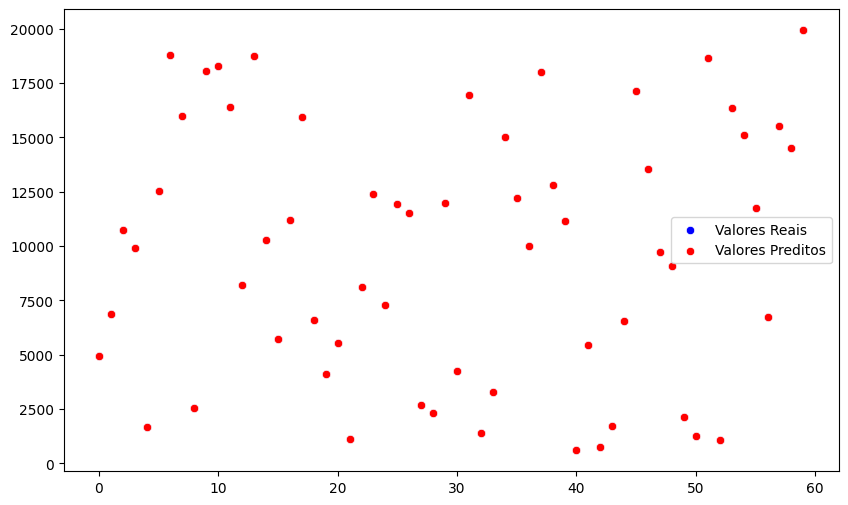

In [38]:
x_axis = range(len(y_test))
plt.figure(figsize=(10,6))
sns.scatterplot(x=x_axis, y=y_test.reshape(-1), color='blue', label='Valores Reais')
sns.scatterplot(x=x_axis, y=y_pred.reshape(-1), color='red', label='Valores Preditos')
plt.legend()
plt.show()

## Análise de resíduos

In [39]:
residuos = y_test - y_pred

In [41]:
residuos_std = zscore(residuos)

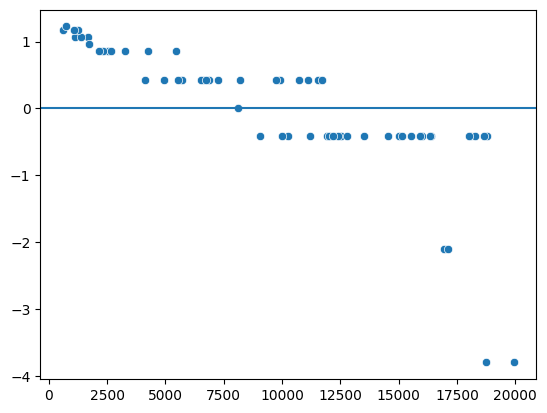

In [42]:
# Verificar linearidade do modelo:
# Se os residuos estiverem entre -2 e +2 (na escala padrão) - indica linearidade

# Verificar a homogeneidade das variancias (Homocesticidade)
# Valores estiver na em torno da reta, temos homocedasticidade, caso contrario, temos alguma tendencia ou padrao (formam cone ou funil), há heterocedasticidade
sns.scatterplot(x=y_pred.reshape(-1), y=residuos_std.reshape(-1))
plt.axhline(y=0)

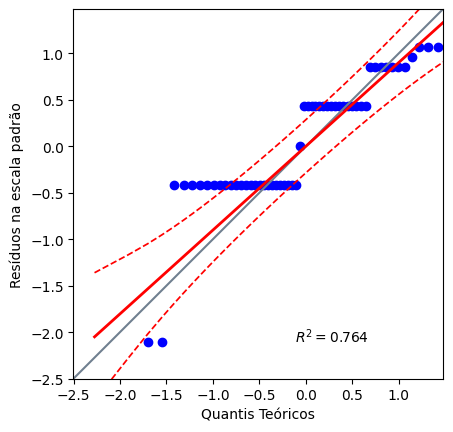

In [44]:
# Checar se residuos seguem uma distribuição normal
# QQ (Quantile-Quantile) Plot
import pingouin as pg
pg.qqplot(residuos_std, dist='norm', confidence=0.95)
plt.xlabel("Quantis Teóricos")
plt.ylabel('Resíduos na escala padrão')
plt.show()

In [45]:
# Teste de Shapiro Wilk
# H0 - segue distribuição normal
# H1 - não segue distribuição normal
# Se p-valor > 0.05 não rejeita H0, caso contrario rejeita
stat_shapiro, p_value_shapiro = shapiro(residuos.reshape(-1))
print("Estatística do teste: {} e P-valor: {}".format(stat_shapiro, p_value_shapiro))

Estatística do teste: 0.7712717571673201 e P-valor: 2.777766294643859e-08


In [46]:
# Teste de Kolmogorov-Smirnov
# H0 - segue distribuição normal
# H1 - não segue distribuição normal
# Se p-valor > 0.05 não rejeita H0, caso contrario rejeita
stat_ks, p_value_ks = kstest(residuos.reshape(-1), 'norm')
print("Estatística do teste: {} e P-valor: {}".format(stat_ks, p_value_ks))

Estatística do teste: 0.499999999998594 e P-valor: 2.1427040527834685e-14


## Predição

In [47]:
model_irrigacao.predict([[15]])

array([[1000.]])